In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
import random

Create a dataset of at least 500 rides containing:
ride_id, city, hour, fare, ride_status


In [2]:
data=[]
faker=Faker()
cities = ["San Francisco","New York", "Chicago", "Los Angeles", "Houston"]

ride_status = ["Completed", "Cancelled", "No Show"]
for i in range(500):
    data.append({
       "ride_id": faker.uuid4(),
        "city": random.choice(cities),
        "hour": random.randint(0, 23),  
        "fare": round(random.uniform(5, 50), 2),  
        "ride_status": random.choice(ride_status)
    })

df=pd.DataFrame(data)
df.to_csv("ride_sharing_details.csv",index=False)


Using Pandas:
Identify peak demand hours per city.


In [3]:
demand = df.groupby(["city", "hour"]).size().reset_index(name="ride_count")
peak_hours = demand.loc[demand.groupby("city")["ride_count"].idxmax()]
print(peak_hours)

              city  hour  ride_count
15         Chicago    15           7
34         Houston    11           9
49     Los Angeles     3           9
72        New York     2           7
107  San Francisco    13           9


Calculate cancellation rates.

In [4]:
total_ride=len(df)
cancel_rides=len(df[df["ride_status"]=="Cancelled"])
cancellation_rate=(cancel_rides/total_ride)*100
print("Cancellation rate is: ",cancellation_rate)

Cancellation rate is:  27.200000000000003


Using NumPy:
Construct a demand index.


In [7]:
demand_index=df.groupby('hour').size().values
base=demand_index[0]
de=(demand_index/base)*100
de

array([100.        ,  52.17391304, 126.08695652, 121.73913043,
        60.86956522,  86.95652174,  78.26086957, 100.        ,
        91.30434783,  95.65217391,  65.2173913 , 113.04347826,
       100.        , 113.04347826,  73.91304348,  82.60869565,
        56.52173913,  65.2173913 , 104.34782609,  82.60869565,
        91.30434783,  95.65217391, 113.04347826, 104.34782609])

Smooth demand trends using numerical techniques

In [10]:
smooth_demand = np.convolve(demand_index, np.ones(3)/3, mode='valid')
print(smooth_demand)

[21.33333333 23.         23.66666667 20.66666667 17.33333333 20.33333333
 20.66666667 22.         19.33333333 21.         21.33333333 25.
 22.         20.66666667 16.33333333 15.66666667 17.33333333 19.33333333
 21.33333333 20.66666667 23.         24.        ]


Using a visualization library:
Plot hourly demand patterns.


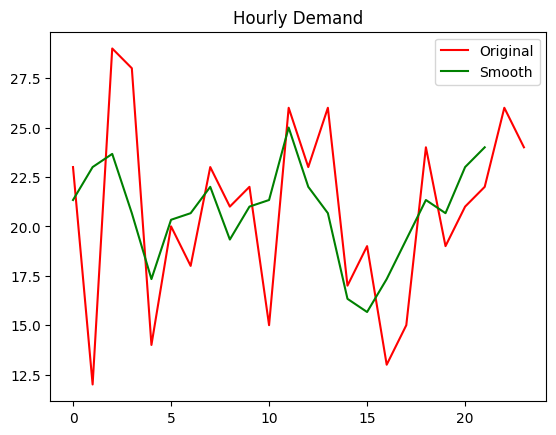

In [13]:

plt.plot(demand_index, label='Original',color="red")
plt.plot(smooth_demand, label='Smooth',color="green")
plt.legend()
plt.title("Hourly Demand")
plt.show()

Compare ride outcomes visually.

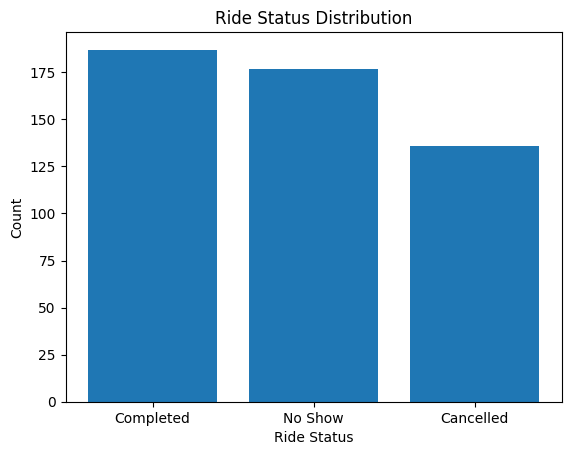

In [16]:
counts = df["ride_status"].value_counts()
plt.bar(counts.index,counts.values)
plt.title("Ride Status Distribution")
plt.xlabel("Ride Status")
plt.ylabel("Count")
plt.show()